# Chapter 5 - Constructing the Ring

## 5.1 Ring Construction

<div align="center"><img src="assets/chapter5_ring_mirror_symmetry.png" width="760"></div>

<p align="center"><em>Figure 1: Mirror symmetry about the centers of each straight section.</em></p>

In the previous chapters, forward and reverse arc lines, forward and reverse straight-section lines, and forward and reverse lines connecting the arcs to the straight sections were constructed. These connecting lines include dispersion suppression and beta-function matching. In this chapter, the entire ring is created based on Figure 1. All that remains is to construct the sections that match each straight section to an arc, including dispersion creation and beta-function matching, as shown in Figure 2.

Does this mean that a separate dispersion creator must be optimized for both the forward and reverse sextants? Fortunately, no. From the mirror symmetry shown in Figure 1, the quadrupole settings for forward dispersion suppression and matching are reused for reverse dispersion creation and matching. Likewise, the reverse dispersion-suppression and matching settings are reused for forward dispersion creation and matching. Therefore, no new optimization is necessary here. All that is needed is to connect the lines together.

<div align="center"><img src="assets/chapter5_sextant_structure.png" width="760"></div>

<p align="center"><em>Figure 2: A sextant of the ring.</em></p>

A forward sextant has the structure

```text
4 forward straight FODO cells
-> forward straight-to-arc connection
-> 20 forward arc FODO cells
-> forward arc-to-straight connection
-> 4 forward straight FODO cells
```

A reverse sextant has the same structure with the mirror-reversed cell definitions. The two mirror pairs are `ARC_TO_SSF <-> SS_TO_ARCR` and `ARC_TO_SSR <-> SS_TO_ARCF`. Three forward-reverse pairs form the complete ring.

In [ ]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()


In [1]:
using SciBmad
using Printf
using CairoMakie

## 5.2 Load the optimized strengths

The preceding notebooks supply the independently optimized forward and reverse arc FODO, dispersion-suppressor, and matching-section strengths. This chapter loads both sets and uses mirror symmetry to construct the corresponding straight-to-arc creator sections.

In [2]:
solution_files = [
    joinpath("lattices", "chapter_1", "chapter1_fodoF_solution.jl"),
    joinpath("lattices", "chapter_1", "chapter1_fodoR_solution.jl"),
    joinpath("lattices", "chapter_2", "chapter2_dispsupF_solution.jl"),
    joinpath("lattices", "chapter_2", "chapter2_dispsupR_solution.jl"),
    joinpath("lattices", "chapter_3", "chapter3_mSSF_solution.jl"),
    joinpath("lattices", "chapter_3", "chapter3_mSSR_solution.jl"),
]

for file in solution_files
    isfile(file) || error("Cannot find $(file). Run the preceding chapters first.")
    include(file)
end

K_ss = 0.351957452649287

println("Loaded optimized strengths.")
@show kQF_arc kQD_arc kQFF1 kQDF1
@show K_QFF2 K_QDF2 K_QFF3 K_QDF3 K_ss

Loaded optimized strengths.
kQF_arc = 0.3126646961206133
kQD_arc = -0.3127984815244765
kQFF1 = 0.31293916256832
kQDF1 = -0.31523567724253193
K_QFF2 = 0.3562548714043402
K_QDF2 = -0.3464014197777525
K_QFF3 = 0.3787975242737728
K_QDF3 = -0.3515071983529922
K_ss = 0.351957452649287


0.351957452649287

## 5.3 Define the element library

The ring is first described as a sequence of symbolic element names. This makes the forward/reverse ordering easy to inspect. The function `make_element` later converts each symbol into a SciBmad element.

In [3]:
L_quad = 0.5
D1_len = 0.609
D2_len = 1.241
DB_len = 5.855
B_len = 6.86
B_angle = pi / 132
BH_angle = B_angle / 2

species_ref = Species("electron")
E_ref = 18e9

quad_strength = Dict(
    :QF => kQF_arc,
    :QD => kQD_arc,
    :QFR => kQF_arc_R,
    :QDR => kQD_arc_R,
    :QFSS => K_ss,
    :QDSS => -K_ss,
    :QFF1 => kQFF1,
    :QDF1 => kQDF1,
    :QFR1 => kQFR1,
    :QDR1 => kQDR1,
    :QFF2 => K_QFF2,
    :QDF2 => K_QDF2,
    :QFF3 => K_QFF3,
    :QDF3 => K_QDF3,
    :QFR2 => K_QFR2,
    :QDR2 => K_QDR2,
    :QFR3 => K_QFR3,
    :QDR3 => K_QDR3,
)

function make_element(name::Symbol)
    haskey(quad_strength, name) && return Quadrupole(name=String(name), L=L_quad, Kn1=quad_strength[name])
    name == :D1 && return Drift(name="D1", L=D1_len)
    name == :D2 && return Drift(name="D2", L=D2_len)
    name == :DB && return Drift(name="DB", L=DB_len)
    name == :B  && return SBend(name="B", L=B_len, angle=B_angle)
    name == :BH && return SBend(name="BH", L=B_len, angle=BH_angle)
    error("Unknown element symbol: $(name)")
end

function make_beamline(names)
    return Beamline([make_element(name) for name in names]; species_ref=species_ref, E_ref=E_ref)
end

make_beamline (generic function with 1 method)

## 5.4 Forward and reverse FODO cells

The reverse cells use the same magnet strengths as the forward cells, but interchange the `D1` and `D2` ordering. Both conventions start with a full horizontally focusing quadrupole.

In [4]:
FODOAF = [:QF,   :D1, :B,  :D2, :QD,   :D1, :B,  :D2]
FODOAR = [:QFR,  :D2, :B,  :D1, :QDR,  :D2, :B,  :D1]
FODOSSF = [:QFSS, :D1, :DB, :D2, :QDSS, :D1, :DB, :D2]
FODOSSR = [:QFSS, :D2, :DB, :D1, :QDSS, :D2, :DB, :D1]

repeat_line(line, n) = reduce(vcat, (copy(line) for _ in 1:n))

println("Forward arc FODO:    ", FODOAF)
println("Reverse arc FODO:    ", FODOAR)
println("Forward straight FODO:", FODOSSF)
println("Reverse straight FODO:", FODOSSR)

Forward arc FODO:    [:QF, :D1, :B, :D2, :QD, :D1, :B, :D2]
Reverse arc FODO:    [:QFR, :D2, :B, :D1, :QDR, :D2, :B, :D1]
Forward straight FODO:[:QFSS, :D1, :DB, :D2, :QDSS, :D1, :DB, :D2]
Reverse straight FODO:[:QFSS, :D2, :DB, :D1, :QDSS, :D2, :DB, :D1]


## 5.5 Connection lines

`ARC_TO_SSF` is the forward dispersion suppressor and matching section. `ARC_TO_SSR` is the corresponding independently optimized reverse connection.

The straight-to-arc lines are generated by mirror symmetry: `SS_TO_ARCR` copies the forward connection strengths, while `SS_TO_ARCF` copies the reverse connection strengths.

In [5]:
ARC_TO_SSF = [
    :QF,   :D1, :BH, :D2, :QD,   :D1, :BH, :D2,
    :QFF1, :D1, :BH, :D2, :QDF1, :D1, :BH, :D2,
    :QFF2, :D1, :DB, :D2, :QDF2, :D1, :DB, :D2,
    :QFF3, :D1, :DB, :D2, :QDF3, :D1, :DB, :D2,
]

SS_TO_ARCF = [
    :QFSS, :D1, :DB, :D2, :QDR3, :D1, :DB, :D2,
    :QFR3, :D1, :DB, :D2, :QDR2, :D1, :DB, :D2,
    :QFR2, :D1, :BH, :D2, :QDR1, :D1, :BH, :D2,
    :QFR1, :D1, :BH, :D2, :QDR,  :D1, :BH, :D2,
]

ARC_TO_SSR = [
    :QFR,  :D2, :BH, :D1, :QDR,  :D2, :BH, :D1,
    :QFR1, :D2, :BH, :D1, :QDR1, :D2, :BH, :D1,
    :QFR2, :D2, :DB, :D1, :QDR2, :D2, :DB, :D1,
    :QFR3, :D2, :DB, :D1, :QDR3, :D2, :DB, :D1,
]

SS_TO_ARCR = [
    :QFSS, :D2, :DB, :D1, :QDF3, :D2, :DB, :D1,
    :QFF3, :D2, :DB, :D1, :QDF2, :D2, :DB, :D1,
    :QFF2, :D2, :BH, :D1, :QDF1, :D2, :BH, :D1,
    :QFF1, :D2, :BH, :D1, :QD,   :D2, :BH, :D1,
]

32-element Vector{Symbol}:
 :QFSS
 :D2
 :DB
 :D1
 :QDF3
 :D2
 :DB
 :D1
 :QFF3
 :D2
 :DB
 :D1
 :QDF2
 ⋮
 :QDF1
 :D2
 :BH
 :D1
 :QFF1
 :D2
 :BH
 :D1
 :QD
 :D2
 :BH
 :D1

## 5.6 Assemble the sextants and ring

In [6]:
SEXTANT_F = vcat(
    repeat_line(FODOSSF, 4),
    SS_TO_ARCF,
    repeat_line(FODOAF, 20),
    ARC_TO_SSF,
    repeat_line(FODOSSF, 4),
)

SEXTANT_R = vcat(
    repeat_line(FODOSSR, 4),
    SS_TO_ARCR,
    repeat_line(FODOAR, 20),
    ARC_TO_SSR,
    repeat_line(FODOSSR, 4),
)

RING_NAMES = repeat_line(vcat(SEXTANT_F, SEXTANT_R), 3)
ring = make_beamline(RING_NAMES)

@printf("Elements per forward sextant: %d\n", length(SEXTANT_F))
@printf("Elements per reverse sextant: %d\n", length(SEXTANT_R))
@printf("Elements in full ring:        %d\n", length(RING_NAMES))

Elements per forward sextant: 288
Elements per reverse sextant: 288
Elements in full ring:        1728


## 5.7 Check the bend count and circumference

The ring closes in angle when the sum of all bend angles is exactly $2\pi$. Geometrical closure additionally requires the final floor position to return to the starting point.

In [7]:
element_length(name::Symbol) = haskey(quad_strength, name) ? L_quad : name == :D1 ? D1_len : name == :D2 ? D2_len : name == :DB ? DB_len : B_len
element_angle(name::Symbol) = name == :B ? B_angle : name == :BH ? BH_angle : 0.0

circumference = sum(element_length(name) for name in RING_NAMES)
total_bend = sum(element_angle(name) for name in RING_NAMES)

@printf("Circumference = %.9f m\n", circumference)
@printf("Total bend    = %.15f rad\n", total_bend)
@printf("Bend error    = %.3e rad\n", total_bend - 2pi)

Circumference = 3834.000000000 m
Total bend    = 6.283185307179608 rad
Bend error    = 2.132e-14 rad


## 5.8 Floor-coordinate closure

For this planar model, straight elements advance along the current reference direction and each bend follows a circular arc.

In [8]:
struct FloorFrame
    x::Float64
    z::Float64
    theta::Float64
end

function advance_floor(frame::FloorFrame, L, angle)
    if abs(angle) < 1e-14
        return FloorFrame(
            frame.x + L * sin(frame.theta),
            frame.z + L * cos(frame.theta),
            frame.theta,
        )
    end

    radius = L / angle
    theta1 = frame.theta + angle
    return FloorFrame(
        frame.x + radius * (cos(frame.theta) - cos(theta1)),
        frame.z + radius * (sin(theta1) - sin(frame.theta)),
        theta1,
    )
end

frames = FloorFrame[FloorFrame(0.0, 0.0, 0.0)]
for name in RING_NAMES
    push!(frames, advance_floor(frames[end], element_length(name), element_angle(name)))
end

finish = frames[end]
@printf("Final x           = %+.6e m\n", finish.x)
@printf("Final z           = %+.6e m\n", finish.z)
@printf("Final theta - 2pi = %+.6e rad\n", finish.theta - 2pi)
@printf("Position error    = %.6e m\n", hypot(finish.x, finish.z))

Final x           = +4.231130e-12 m
Final z           = +1.153566e-11 m
Final theta - 2pi = +2.131628e-14 rad
Position error    = 1.228715e-11 m


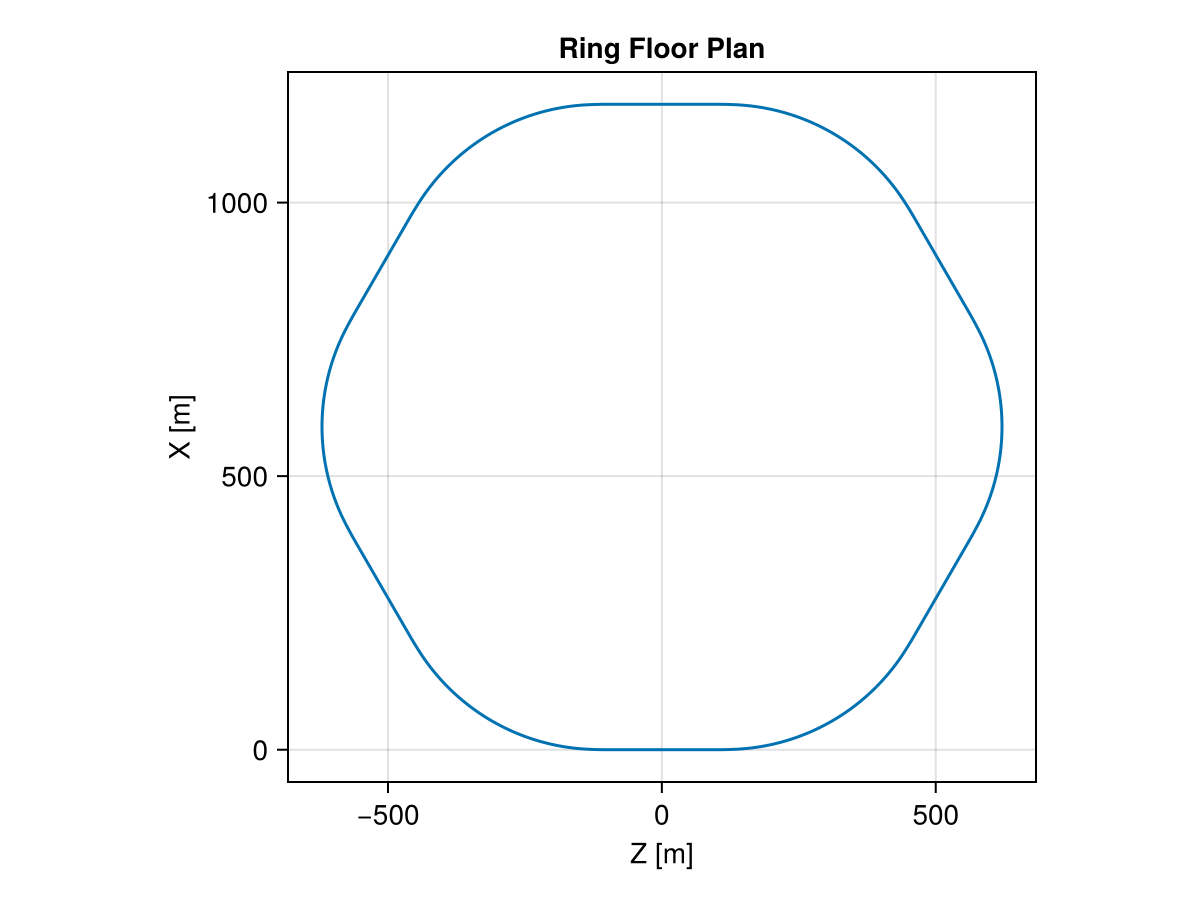

In [10]:
lines(
    [f.z for f in frames],
    [f.x for f in frames];
    axis = (;
        aspect = DataAspect(),
        xlabel = "Z [m]",
        ylabel = "X [m]",
        title = "Ring Floor Plan",
    ),
)

## 5.9 Optional full-ring optics check

After the geometrical construction is verified, calculate the periodic full-ring optics. This is a stronger check because it tests whether the mirrored connection sections are also optically consistent.

The following calculation asks SciBmad for the periodic optics of the complete ring. Inspect the full-ring tunes, the continuity of the beta functions, and whether the horizontal dispersion is approximately zero in the straight sections.

A successful result verifies that the independently optimized forward and reverse sections and their mirrored creator sections form one optically consistent ring.

In [9]:
tw_ring = twiss(ring)
tw_ring

Twiss:
 coasting_beam = true
 tunes[1:3]    = [Qx, Qy, slip]
 table         has columns: beamline_index, name, s, phi_1, beta_1, alpha_1, phi_2, beta_2, alpha_2, phi_3, gamma_c, c11, c12, c21, c22, orbit_x, orbit_px, orbit_y, orbit_py, orbit_z, orbit_pz

## Exercises

1. Compare each straight-to-arc creator line with the corresponding mirrored arc-to-straight connection.
2. Calculate the periodic full-ring Twiss solution and report the horizontal and vertical tunes.
3. Confirm that the dispersion is zero in the centers of all six straight sections.
4. Change one half-bend to a full bend and explain the resulting geometric closure error.